# Airline Sentiment<br>
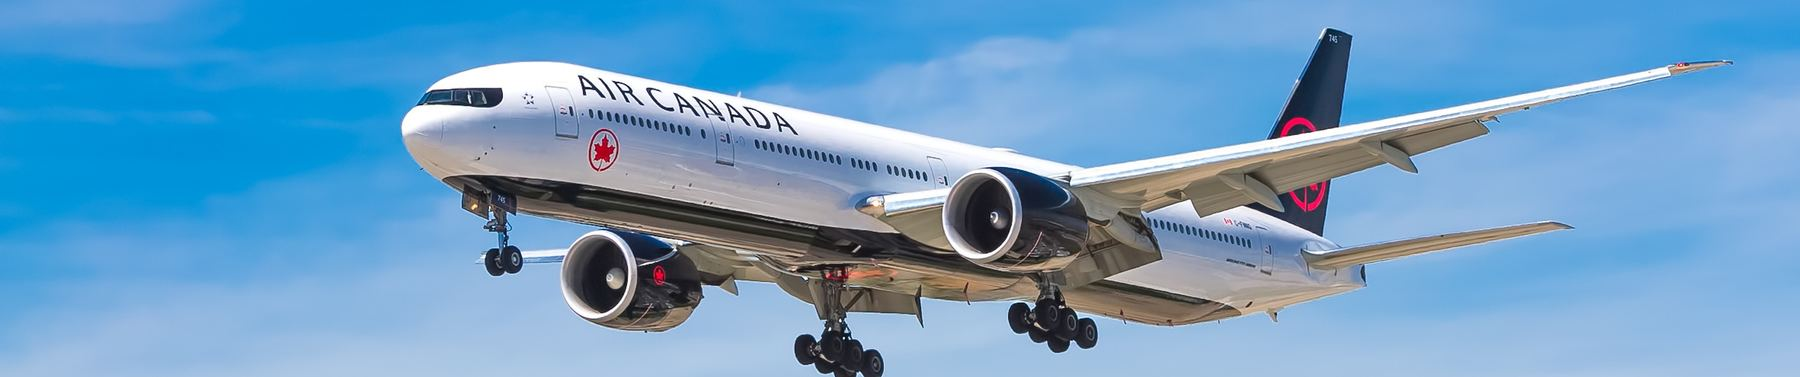
https://www.kaggle.com/datasets/welkin10/airline-sentiment

In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

conn = sqlite3.connect("../data/raw/database.sqlite")

# Tabellen anzeigen
tables = pd.read_sql_query("""
SELECT name
FROM sqlite_master
WHERE type='table';
""", conn)

print(tables)

# Datentabelle laden
df = pd.read_sql_query("""
SELECT *
FROM Tweets;
""", conn)

# conn.close()

df.head()

     name
0  Tweets


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,567588278875213824,neutral,1.0,,,Delta,,JetBlueNews,,0,@JetBlue's new CEO seeks the right balance to ...,,2015-02-16 23:36:05 -0800,USA,Sydney
1,567590027375702016,negative,1.0,Can't Tell,0.6503,Delta,,nesi_1992,,0,@JetBlue is REALLY getting on my nerves !! 😡😡 ...,,2015-02-16 23:43:02 -0800,undecided,Pacific Time (US & Canada)
2,567591480085463040,negative,1.0,Late Flight,0.346,United,,CPoutloud,,0,@united yes. We waited in line for almost an h...,,2015-02-16 23:48:48 -0800,"Washington, DC",
3,567592368451248130,negative,1.0,Late Flight,1,United,,brenduch,,0,@united the we got into the gate at IAH on tim...,,2015-02-16 23:52:20 -0800,,Buenos Aires
4,567594449874587648,negative,1.0,Customer Service Issue,0.3451,Southwest,,VahidESQ,,0,@SouthwestAir its cool that my bags take a bit...,,2015-02-17 00:00:36 -0800,"Los Angeles, CA",Pacific Time (US & Canada)


In [5]:
# erste zeilen
df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,567588278875213824,neutral,1.0,,,Delta,,JetBlueNews,,0,@JetBlue's new CEO seeks the right balance to ...,,2015-02-16 23:36:05 -0800,USA,Sydney
1,567590027375702016,negative,1.0,Can't Tell,0.6503,Delta,,nesi_1992,,0,@JetBlue is REALLY getting on my nerves !! 😡😡 ...,,2015-02-16 23:43:02 -0800,undecided,Pacific Time (US & Canada)
2,567591480085463040,negative,1.0,Late Flight,0.346,United,,CPoutloud,,0,@united yes. We waited in line for almost an h...,,2015-02-16 23:48:48 -0800,"Washington, DC",
3,567592368451248130,negative,1.0,Late Flight,1,United,,brenduch,,0,@united the we got into the gate at IAH on tim...,,2015-02-16 23:52:20 -0800,,Buenos Aires
4,567594449874587648,negative,1.0,Customer Service Issue,0.3451,Southwest,,VahidESQ,,0,@SouthwestAir its cool that my bags take a bit...,,2015-02-17 00:00:36 -0800,"Los Angeles, CA",Pacific Time (US & Canada)


In [6]:
# letzte zeilen
df.tail()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
14480,570309308937842688,neutral,0.6869,,,Delta,,Oneladyyouadore,,0,@JetBlue I hope so because I fly very often an...,,2015-02-24 11:48:29 -0800,Georgia,Quito
14481,570309340952993796,neutral,1.0000,,,US Airways,,DebbiMcGinnis,,0,@USAirways is a DM possible if you aren't foll...,,2015-02-24 11:48:37 -0800,Missourah,Hawaii
14482,570309345281486848,positive,0.6469,,,Delta,,jaxbra,,0,@JetBlue Yesterday on my way from EWR to FLL j...,,2015-02-24 11:48:38 -0800,"east brunswick, nj",Atlantic Time (Canada)
14483,570310144459972608,negative,1.0000,Customer Service Issue,1,US Airways,,GAKotsch,,0,@USAirways and when will one of these agents b...,,2015-02-24 11:51:48 -0800,,Atlantic Time (Canada)
14484,570310600460525568,negative,0.6292,Flight Booking Problems,0.3146,US Airways,,jhazelnut,,0,@USAirways is there a better time to call? My...,,2015-02-24 11:53:37 -0800,,


In [7]:
# größe des datensatzes
df.shape

(14485, 15)

In [8]:
list(df.columns)

['tweet_id',
 'airline_sentiment',
 'airline_sentiment_confidence',
 'negativereason',
 'negativereason_confidence',
 'airline',
 'airline_sentiment_gold',
 'name',
 'negativereason_gold',
 'retweet_count',
 'text',
 'tweet_coord',
 'tweet_created',
 'tweet_location',
 'user_timezone']

In [9]:
df.describe(include="all")

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
count,1.448500e+04,14485,14485.000000,14485,14485,14485,14485,14485,14485,14485.000000,14485,14485,14485,14485,14485
unique,NaN,3,NaN,11,1404,6,4,7701,14,NaN,14427,833,14247,3082,86
top,NaN,negative,NaN,,,United,,JetBlueNews,,NaN,@united thanks,,2015-02-23 06:57:24 -0800,,
freq,NaN,9082,NaN,5403,4069,3822,14445,63,14453,NaN,6,13478,3,4687,4775
mean,5.692072e+17,NaN,0.899958,NaN,NaN,NaN,NaN,NaN,NaN,0.083397,NaN,NaN,NaN,NaN,NaN
std,7.756739e+14,NaN,0.162961,NaN,NaN,NaN,NaN,NaN,NaN,0.749632,NaN,NaN,NaN,NaN,NaN
min,5.675883e+17,NaN,0.335000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN
25%,5.685515e+17,NaN,0.692300,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN
50%,5.694398e+17,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN
75%,5.698811e+17,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN


In [10]:
# fehlende werte
df.isnull().sum()

tweet_id                        0
airline_sentiment               0
airline_sentiment_confidence    0
negativereason                  0
negativereason_confidence       0
airline                         0
airline_sentiment_gold          0
name                            0
negativereason_gold             0
retweet_count                   0
text                            0
tweet_coord                     0
tweet_created                   0
tweet_location                  0
user_timezone                   0
dtype: int64

In [11]:
# doppelte zeilen
df.duplicated().sum()

np.int64(0)

In [12]:
df.columns

Index(['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence',
       'negativereason', 'negativereason_confidence', 'airline',
       'airline_sentiment_gold', 'name', 'negativereason_gold',
       'retweet_count', 'text', 'tweet_coord', 'tweet_created',
       'tweet_location', 'user_timezone'],
      dtype='object')

In [13]:
df['airline'].value_counts()

airline
United            3822
US Airways        2913
American          2604
Southwest         2420
Delta             2222
Virgin America     504
Name: count, dtype: int64

In [15]:
df = pd.read_sql("SELECT negativereason FROM Tweets", conn)
df.head()

,negativereason
0,
1,Can't Tell
2,Late Flight
3,Late Flight
4,Customer Service Issue


In [16]:
query = """
SELECT airline, airline_sentiment, COUNT(*) AS tweet_count
FROM Tweets
WHERE airline_sentiment =='negative'
GROUP BY airline, airline_sentiment
ORDER BY airline, tweet_count DESC;
"""

sentiment_counts_df = pd.read_sql(query, conn)
sentiment_counts_df

,airline,airline_sentiment,tweet_count
0,American,negative,1864
1,Delta,negative,955
2,Southwest,negative,1186
3,US Airways,negative,2263
4,United,negative,2633
5,Virgin America,negative,181


In [19]:
print(df.loc[1].isna().any)

<bound method Series.any of negativereason    False
Name: 1, dtype: bool>


In [20]:
df.isnull().sum().sort_values(ascending=False)

negativereason    0
dtype: int64

In [21]:
missing = (df.isnull().mean() * 100).round(2)

pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": missing
}).sort_values("Percentage", ascending=False)

,Missing Values,Percentage
negativereason,0,0.0
